# 03 — Profit-Risk Analysis: From PD Scores to Business Decisions

## What This Notebook Does

The model from Notebook 02 gives us one number per loan: a calibrated **probability of default (PD)**. That number alone doesn't make a lending decision. Should you approve a loan with PD = 25%? What about 18%? 32%? The answer depends on the *economics* of the specific loan — how much money is at stake, how much you'd recover if it defaults, and how much interest you earn if it pays.

This notebook answers: **given the model's risk scores and real loan economics, what approval policy maximizes total portfolio profit?**

It does this in three steps:

| Step | What | Why |
|---|---|---|
| **1. LGD + EL** | Compute expected dollar loss per loan using `EL = PD × LGD × EAD` | Converts abstract probability into dollars at risk |
| **2. Profit curve** | Sweep approval thresholds, measure realized profit at each | Finds the PD cutoff that maximizes portfolio return |
| **3. WoE / IV scorecard** | Rank features by Information Value | Regulatory-ready framing for Basel / IFRS 9 |

### The Core Formula

$$\text{Expected Loss} = \underbrace{PD}_{\text{model output}} \times \underbrace{LGD}_{\text{recovery rate}} \times \underbrace{EAD}_{\text{loan size}}$$

- **PD** = calibrated probability of default from Notebook 02 — isotonically calibrated so 0.20 genuinely means ~20% chance of default.
- **EAD** (Exposure at Default) = `funded_amnt` — the actual dollars Lending Club disbursed. The maximum the lender can lose.
- **LGD** (Loss Given Default) = `1 − recovery_rate` — of every dollar at risk, what fraction is actually lost after partial repayments and post-default recoveries.

**Why each component matters independently:**

A 25% PD is very different risk depending on loan size. A $2,000 loan with PD = 0.30 has EL = $0.30 × 0.623 × $2,000 = **$374**. A $30,000 loan with PD = 0.30 has EL = $0.30 × 0.623 × $30,000 = **$5,607**. Same risk score. 15× different dollar exposure. The formula is what converts probability into a real business number.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as C
from src import profit as P
sns.set_style("whitegrid")

test = pd.read_parquet(C.PROCESSED_DIR / "test_with_pd.parquet")
print("Scored hold-out loans:", test.shape)
test[["pd_score", "funded_amnt", "total_pymnt", "recoveries", C.TARGET]].head()

Scored hold-out loans: (85452, 33)


,pd_score,funded_amnt,total_pymnt,recoveries,target
3,0.095521,5000,5980.713035,0.0,0
5,0.148187,5000,5810.466355,0.0,0
6,0.043201,23000,24378.935977,0.0,0
11,0.078429,33000,36580.425679,0.0,0
12,0.127710,4200,4684.463697,0.0,0


## 1. LGD and Expected Loss

### What Is LGD?

**Loss Given Default** is the fraction of the loan amount that is ultimately lost when a borrower defaults. It is NOT 100% — borrowers typically make some payments before defaulting, and there is a post-charge-off recovery process (collections agencies, settlements). LGD captures what's left after all of that.

**How it's computed per loan (for defaulted loans only):**

```
principal_lost = funded_amnt − total_rec_prncp − recoveries
LGD            = principal_lost / funded_amnt   (clipped to [0, 1])
```

Where:
- `total_rec_prncp` = principal already repaid before the default event
- `recoveries` = post-charge-off gross recovery (collections, debt sales, settlements)

**Portfolio LGD** is the average of these per-loan realized LGDs across all defaults. It is a useful summary, but realized LGD is *bimodal* (a spike near total loss plus a spread of partial recoveries), so a single average is a crude assumption. The pipeline therefore also fits a **per-loan two-stage LGD model** (cure classifier + severity regressor — see `src/lgd.py`) that predicts each applicant's LGD from origination features and beats the portfolio constant (MAE 0.185 vs 0.196). The expected-loss formula uses that per-loan `lgd_pred` when available, falling back to the portfolio average otherwise. On this out-of-time cohort the portfolio average is elevated (~0.74) because recent defaults have had little time to recover.

### Reading the Two Charts

**Left — LGD Distribution (histogram of defaulted loans):**

The distribution piles up between **0.6 and 0.85** — most defaulted loans lost 60–85 cents per dollar lent. The peak around 0.70–0.80 is the typical pattern: borrowers made some payments for several months then went silent, and post-default collections recovered only a small residual amount.

- **Near 0.0 (rare):** Borrower defaulted very late — almost all principal was already repaid. Lender barely lost anything.
- **Near 1.0 (rare):** Borrower defaulted almost immediately, made almost no payments, collections recovered nothing. Full loss.
- **Bulk at 0.65–0.80:** The typical default — 12–18 months of payments made, then charge-off with modest recovery.

The portfolio average of **LGD = 0.623** means on a typical default, the lender loses 62.3 cents per dollar. The other 37.7 cents was recovered through prior payments and post-default collections.

**Right — Expected Loss vs PD (scatter plot):**

Every dot is one loan. X-axis is the model's predicted PD; Y-axis is expected dollar loss (`PD × 0.623 × funded_amnt`).

The **widening fan shape** is the key pattern. At low PD (left), all dots cluster near zero regardless of loan size — a small probability multiplied by any reasonable loan amount is still a small dollar loss. As PD increases (moving right), the dots spread out vertically. The spread is entirely due to **loan size**: a high-PD borrower with a $35,000 loan sits near the top of the chart ($12,000–$14,000 expected loss), while an equally high-PD borrower with a $3,500 loan sits near the bottom.

**The critical takeaway:** PD alone cannot make a lending decision. A 30% default probability means something very different for a $2,000 loan vs a $30,000 loan. The EL formula is what converts the abstract risk score into the dollar figure you actually care about.

Portfolio LGD (avg over defaults): 0.587
Total expected loss on the book:   $132,023,062
Total realized profit (all loans): $44,697,769


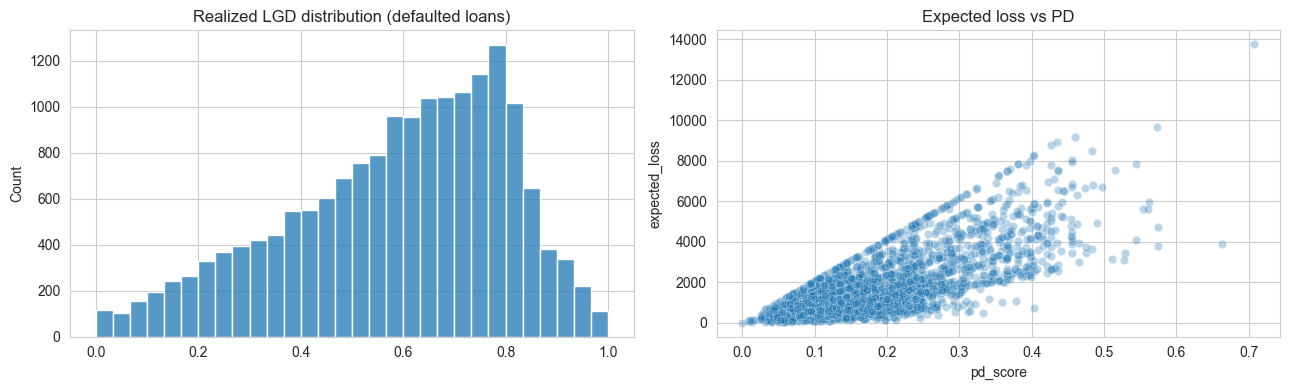

In [2]:
lgd = P.portfolio_lgd(test)
test["expected_loss"] = P.expected_loss(test, lgd=lgd)
test["realized_profit"] = P.realized_profit(test)

print(f"Portfolio LGD (avg over defaults): {lgd:.3f}")
print(f"Total expected loss on the book:   ${test['expected_loss'].sum():,.0f}")
print(f"Total realized profit (all loans): ${test['realized_profit'].sum():,.0f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(P.realized_lgd(test[test[C.TARGET] == 1]), bins=30, ax=ax[0])
ax[0].set_title("Realized LGD distribution (defaulted loans)")
sns.scatterplot(x="pd_score", y="expected_loss", data=test.sample(3000), alpha=0.3, ax=ax[1])
ax[1].set_title("Expected loss vs PD"); plt.tight_layout(); plt.show()

Optimal approval policy:
  threshold             : 0.2600
  approval_rate         : 0.8257
  total_profit          : 58,124,095.6597
  default_rate_approved : 0.1570


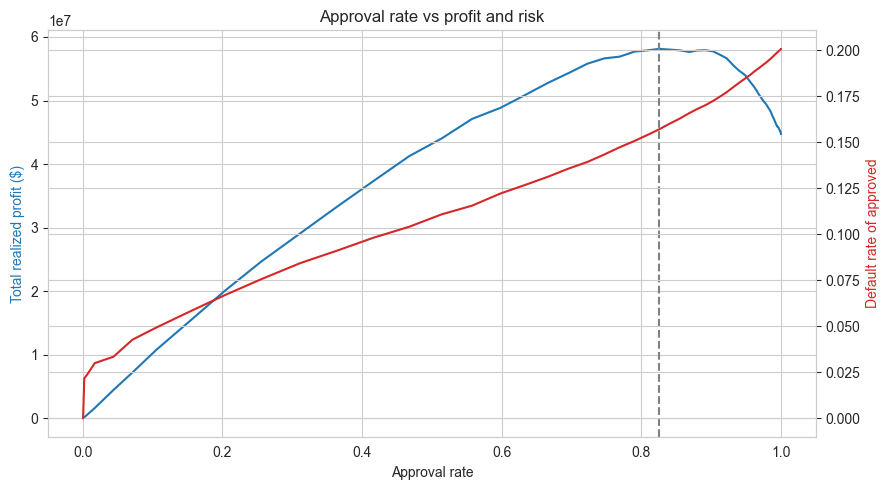

In [3]:
curve = P.profit_curve(test)
best = P.optimal_threshold(curve)
print("Optimal approval policy:")
for k in ["threshold", "approval_rate", "total_profit", "default_rate_approved"]:
    print(f"  {k:22s}: {best[k]:,.4f}")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(curve["approval_rate"], curve["total_profit"], color="tab:blue")
ax1.set_xlabel("Approval rate"); ax1.set_ylabel("Total realized profit ($)", color="tab:blue")
ax1.axvline(best["approval_rate"], ls="--", color="grey")
ax2 = ax1.twinx()
ax2.plot(curve["approval_rate"], curve["default_rate_approved"], color="tab:red")
ax2.set_ylabel("Default rate of approved", color="tab:red")
plt.title("Approval rate vs profit and risk"); plt.tight_layout(); plt.show()

## 3. Scorecard View: Weight of Evidence / Information Value

### Why This Matters

The ML model is powerful but speaks the language of gradients and SHAP values. Bank regulators, model risk management teams, and credit rating agencies speak a different language: **scorecards, Weight of Evidence, and Information Value**. This section translates the model's findings into that language.

WoE/IV is the standard framework under **Basel II/III** and **IFRS 9** for validating credit scoring models. Every major bank's internal model validation team will ask for IV tables before approving a model for production.

### Theory: Weight of Evidence (WoE)

For each feature, we split loans into bins (10 quantile bins for numeric features). For each bin, WoE measures how much that bin skews toward good (fully paid) vs bad (defaulted) loans:

$$\text{WoE}_{bin} = \ln\left(\frac{\% \text{ of all Good loans in this bin}}{\% \text{ of all Bad loans in this bin}}\right)$$

- **Positive WoE:** this bin has proportionally more good loans than bad — a safer segment
- **Negative WoE:** this bin has more bad loans than good — a riskier segment
- **WoE = 0:** this bin has the same good/bad ratio as the portfolio average — no discriminating power

The WoE values directly encode the direction and magnitude of each feature bin's risk signal. They are used in traditional scorecards to assign point scores to each bin.

### Theory: Information Value (IV)

IV summarizes the *total* predictive power of a feature across all its bins:

$$\text{IV} = \sum_{bins} (\%Good_{bin} - \%Bad_{bin}) \times WoE_{bin}$$

**Standard IV thresholds used by bank model validators:**

| IV | Predictive Power |
|---|---|
| < 0.02 | Useless — typically dropped |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.50 | Strong |
| > 0.50 | Suspicious (check for data leakage) |

### Actual Results

| Feature | IV | Interpretation |
|---|---|---|
| `term_months` | **0.186** | **Medium** — strongest independent origination-time signal. The 36 vs 60 month split carries substantial separating power on its own. |
| `dti` | 0.261 | Weak-medium — meaningful but not dominant as a standalone feature. |
| `revol_util` | 0.033 | Weak but present — the monotonic risk pattern from EDA shows up here. |
| `annual_inc` | 0.029 | Weak — income alone is noisy (extreme outliers, high variance across loan types). |
| `inq_last_6mths` | 0.020 | Barely above the "useless" threshold as a standalone feature. |
| `open_acc` | 0.006 | Weak — limited standalone separating power. |
| `emp_length_num` | 0.003 | Essentially useless by IV standards — fully consistent with the flat univariate chart in EDA. |

### What the IV Results Confirm

**`term_months` dominates at IV = 0.186.** This is consistent with two completely independent methods:
- **SHAP** (game-theoretic, from the XGBoost model): `term_months` ranked #1 with mean |SHAP| = 0.308
- **IV** (actuarial, from binning): `term_months` ranked #1 with IV = 0.186

When two completely different analytical frameworks independently agree on the feature ranking, that's strong evidence the signal is real and not an artifact of one particular method.

**Features with IV < 0.02** (`open_acc`, `emp_length_num`) would be dropped from a traditional regulatory scorecard. In the ML model they may still contribute marginal information in combination with other features — which is why they appear in the SHAP chart but would be eliminated in a standalone scorecard submission.

**The WoE/IV framing is what you present to regulators.** It is transparent, auditable, and produces a literal point-score table a loan officer can look up without running a model. The ML model and the IV scorecard are complementary tools — the model maximizes predictive power, the scorecard provides interpretability and regulatory defensibility.

In [4]:
candidate_feats = ["dti", "annual_inc", "revol_util", "open_acc", "inq_last_6mths",
                   "emp_length_num", "term_months"]
iv = {f: P.information_value(test[f], test[C.TARGET]) for f in candidate_feats if f in test}
iv = pd.Series(iv).sort_values(ascending=False)
display(iv.to_frame("information_value").round(4))

# Persist economics for the Streamlit app (LGD + optimal threshold)
(C.MODELS_DIR / "economics.json").write_text(json.dumps({
    "portfolio_lgd": float(lgd),
    "optimal_threshold": float(best["threshold"]),
}, indent=2))
print("Saved economics.json for the app.")

,information_value
term_months,0.2852
dti,0.0815
inq_last_6mths,0.0468
annual_inc,0.0304
revol_util,0.0197
open_acc,0.0109
emp_length_num,0.0020


Saved economics.json for the app.
